# Projet Serie Temporelle

![Nile River](img/Nile-River.jpg)

## Analyse du débit annuel du Nil

Étude et modélisation d’une série temporelle réelle à partir du dataset Nile.

## Contexte

Le Nil est l’un des fleuves les plus importants au monde, jouant un rôle essentiel dans le développement de l’Égypte.

Le dataset **Nile**, disponible en R.

L’analyse de cette série temporelle permet de mieux comprendre :
- les variations du débit au fil du temps
- les changements structurels
- les tendances à long terme

## Objectifs

L’objectif de ce projet est d’exploiter la série temporelle du Nil afin de :

- Analyser son comportement (tendance, variabilité)
- Étudier les dépendances temporelles (ACF, PACF)
- Vérifier la stationnarité
- Appliquer des transformations si nécessaire (log, différenciation)
- Construire des modèles de prévision (ARIMA, lissage exponentiel, régression)
- Évaluer les performances des modèles

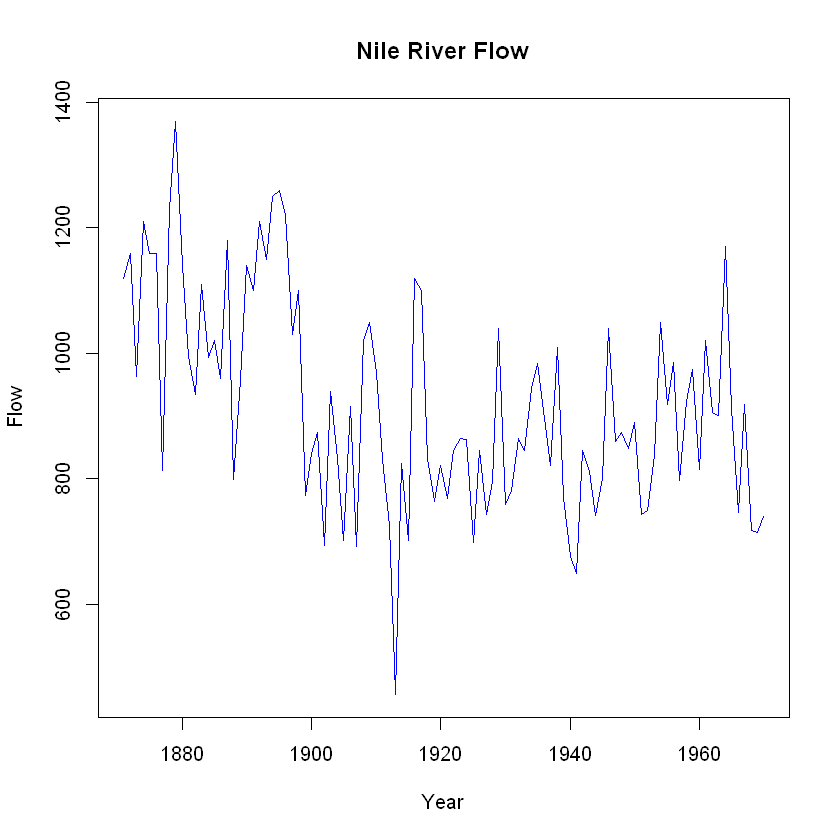

In [1]:
# Charger le dataset Nile
data(Nile)

# Afficher le graphique
plot(Nile,
     main = "Nile River Flow",
     ylab = "Flow",
     xlab = "Year",
     col = "blue",
     type = "l")

In [2]:
start(Nile)   # début
end(Nile)     # fin
frequency(Nile)  # fréquence

[1] 1871    1

[1] 1970    1

[1] 1

On peut observer que l’étude de cette série temporelle s’étend de 1871 à 1970.

La fréquence est égale à 1, ce qui signifie que les données sont annuelles.

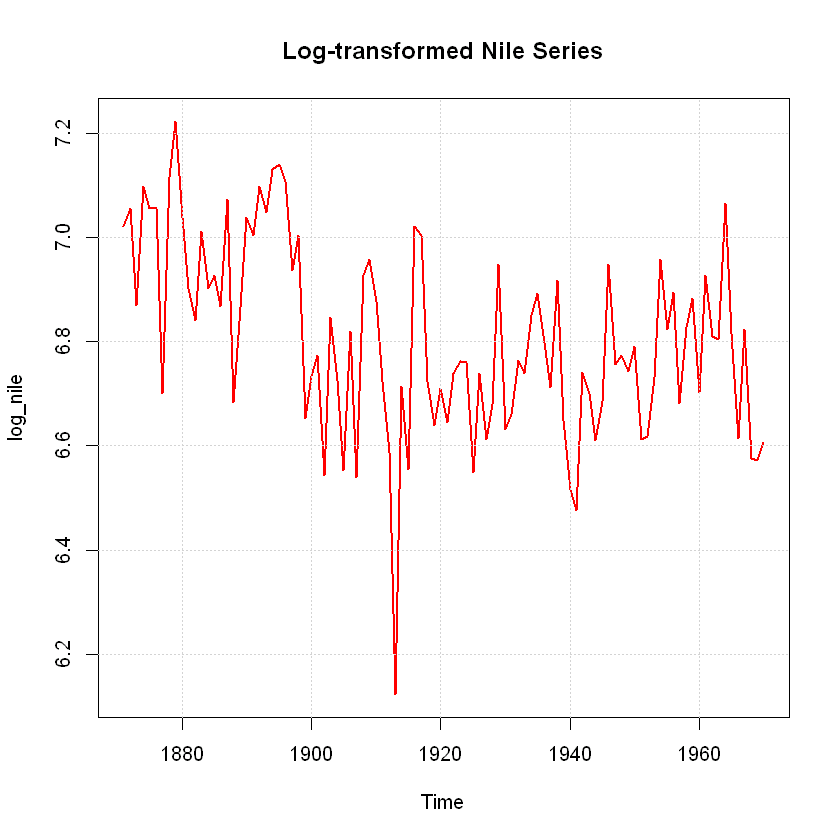

In [3]:
log_nile <- log(Nile)

plot(log_nile,
     main = "Log-transformed Nile Series",
     col = "red",
     lwd = 2)
grid()

In [4]:
help(Nile)

Nile                 package:datasets                  R Documentation

_F_l_o_w _o_f _t_h_e _R_i_v_e_r _N_i_l_e

_D_e_s_c_r_i_p_t_i_o_n:

     Measurements of the annual flow of the river Nile at Aswan
     (formerly 'Assuan'), 1871-1970, in 10^8 m^3, "with apparent
     changepoint near 1898" (Cobb(1978), Table 1, p.249).

_U_s_a_g_e:

     Nile
     
_F_o_r_m_a_t:

     A time series of length 100.

_S_o_u_r_c_e:

     Durbin, J. and Koopman, S. J. (2001).  _Time Series Analysis by
     State Space Methods_.  Oxford University Press.

_R_e_f_e_r_e_n_c_e_s:

     Balke, N. S. (1993).  Detecting level shifts in time series.
     _Journal of Business and Economic Statistics_, *11*, 81-92.
     doi:10.2307/1391308 <https://doi.org/10.2307/1391308>.

     Cobb, G. W. (1978).  The problem of the Nile: conditional solution
     to a change-point problem.  _Biometrika_ *65*, 243-51.
     doi:10.2307/2335202 <https://doi.org/10.2307/233

marcus : lissage exponentiel

flavio : arima

dhia : sarima

In [ ]:
# check saisonality
plot(decompose(data))


ERROR: Error in decompose(data): la série temporelle a moins de 2 périodes


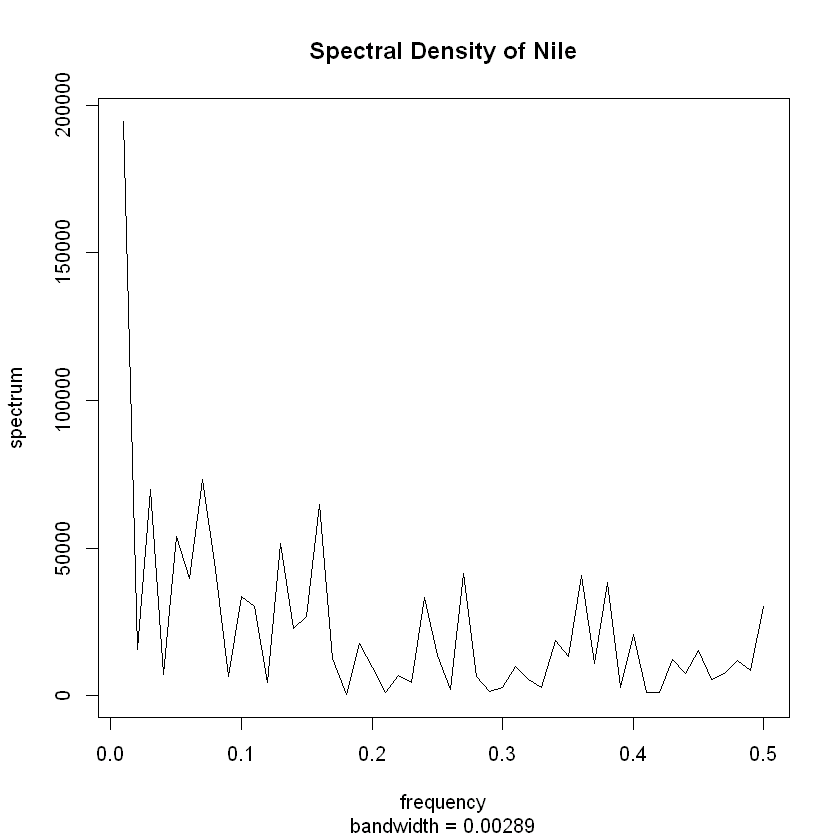

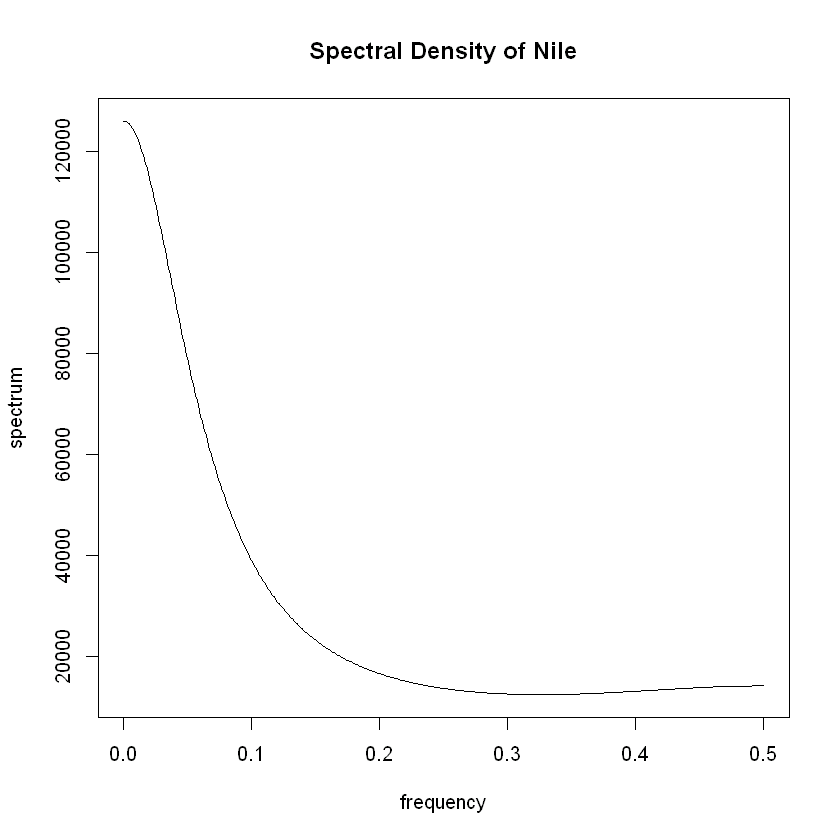

In [11]:
# densité spectrale
spectrum(Nile, log = "no", main = "Spectral Density of Nile")

# densité spectrale AR(2)
spectrum(Nile, log = "no", main = "Spectral Density of Nile", method = "ar", order = 2)

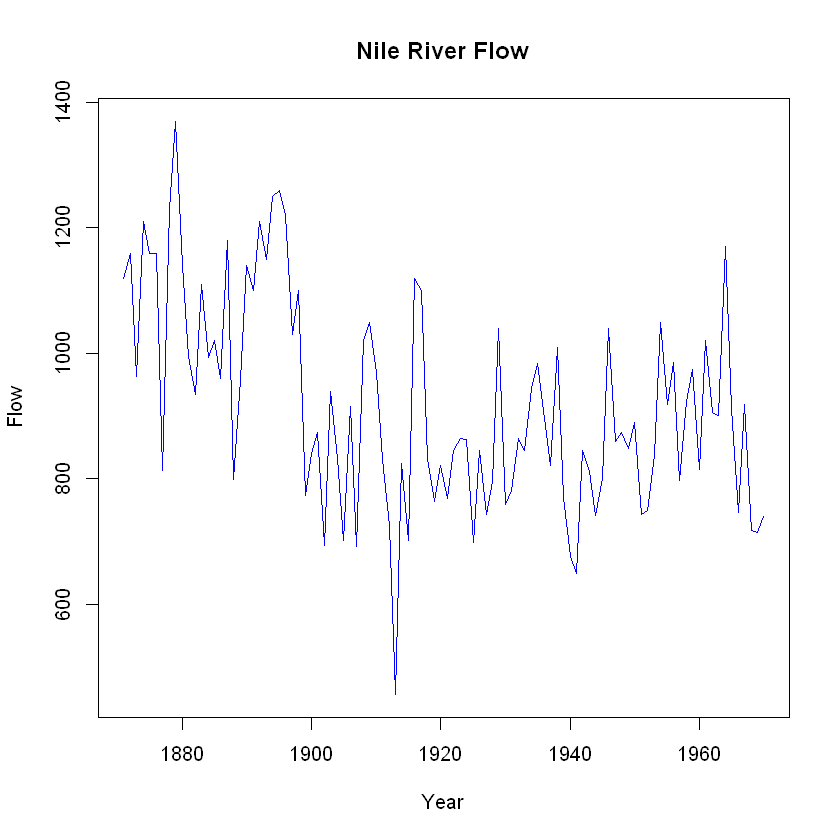

In [12]:
# analyser tendance
plot(Nile,
     main = "Nile River Flow",
     ylab = "Flow",
     xlab = "Year",
     col = "blue",
     type = "l")

In [14]:
install.packages("feasts")
install.packages("tsibble")

Installation du package dans 'C:/Users/dhidh/AppData/Local/R/win-library/4.4'
(car 'lib' n'est pas spécifié)

installation des dépendances 'BH', 'distributional', 'ggdist', 'anytime', 'warp', 'fabletools', 'tsibble', 'slider', 'ggtime'




le package 'BH' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'distributional' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'ggdist' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'anytime' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'warp' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'fabletools' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'tsibble' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'slider' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'ggtime' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'feasts' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\dhidh\AppData\Local\Temp\RtmpYrK1gi\downloaded_packages


Installation du package dans 'C:/Users/dhidh/AppData/Local/R/win-library/4.4'
(car 'lib' n'est pas spécifié)



le package 'tsibble' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\dhidh\AppData\Local\Temp\RtmpYrK1gi\downloaded_packages


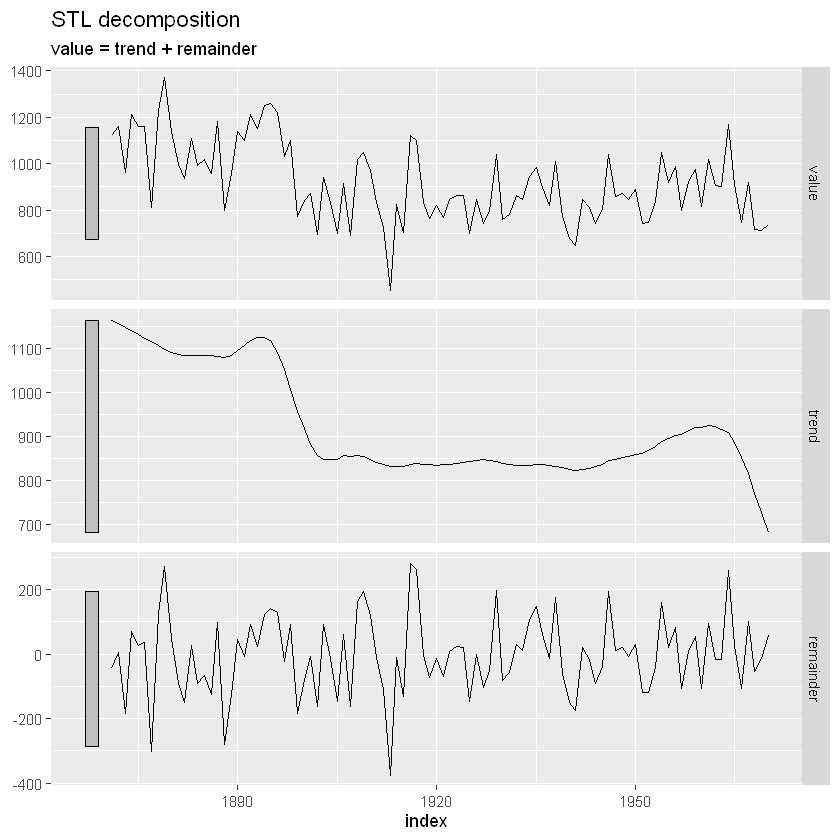

In [16]:
library(feasts)
library(tsibble)

nile_ts <- as_tsibble(Nile)
nile_ts %>%
  model(STL(value ~ trend(window = 7))) %>%
  components() %>%
  autoplot()

